# Autograph Development - Part II
***111725JAA & Claude***

Part I just covered some basics for creating or loading graph data. We need to use this information to numerically define the EoM matrix at each frequency point. From here we can always compute the scattering, as well as other basics like steady state-equilibrium occupancy.

In [218]:
# Add the graphulator package to the path
import sys
from pathlib import Path

# Navigate to the src directory
graphulator_src = Path.cwd().parent.parent / 'src'
if str(graphulator_src) not in sys.path:
    sys.path.insert(0, str(graphulator_src))

print(f"Added to path: {graphulator_src}")


# Core imports
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Import autograph module
from graphulator.autograph import GraphExtractor, load_pgraph


# since we're actively developing, auto-reload modules on change
%load_ext autoreload
%autoreload 2


# Display settings
# %matplotlib inline
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['font.size'] = 12

Added to path: /Users/joe/WORKWORKWORK.nosync/PROGRAMMING/PYTHON/my_packages/graphulator/src
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Computing Accumulated Pump Frequencies

For coupled mode theory, we need to track the accumulated pump frequency offset along each branch from the root. This is used to compute chord pump frequencies when edges close loops between branches.

The `GraphExtractor` class now automatically computes these frequencies when you extract a graph, and updates them automatically when you modify parameters. You can access them using the getter methods.

In [2]:
# Example: Accumulated frequencies are computed automatically
# Create example graph_data structure with conjugated nodes
example_graph_data = {
    'nodes': [
        {'node_id': 0, 'label': 'a', 'pos': (0.0, 0.0), 'conj': False, 'freq': 2.0, 'B_int': 0.0, 'B_ext': 0.0},
        {'node_id': 1, 'label': 'b', 'pos': (1.0, 0.0), 'conj': True, 'freq': 6.0, 'B_int': 0.0, 'B_ext': 0.0},   # Conjugated
        {'node_id': 2, 'label': 'c', 'pos': (0.5, 1.0), 'conj': False, 'freq': 5.0, 'B_int': 0.0, 'B_ext': 0.0},
        {'node_id': 3, 'label': 'd', 'pos': (1.5, 1.0), 'conj': True, 'freq': 8.0, 'B_int': 0.0, 'B_ext': 0.0},   # Conjugated
    ],
    'edges': [
        {'from_node_id': 0, 'to_node_id': 1, 'is_self_loop': False, 'f_p': 8.0, 'rate': 1.0, 'phase': 0.0},
        {'from_node_id': 1, 'to_node_id': 2, 'is_self_loop': False, 'f_p': 11.0, 'rate': 1.0, 'phase': 0.0},
        {'from_node_id': 2, 'to_node_id': 3, 'is_self_loop': False, 'f_p': 13.0, 'rate': 1.0, 'phase': 0.0},
    ],
    'tree_edges': [
        [[0, 1, 8.0], [1, 2, 11.0], [2, 3, 13.0]]  # Mixed conversion/amplification
    ],
    'chord_edges': [],
    'frequency': {'start': 0.0, 'stop': 10.0, 'points': 100},
    'basis_order': [0, 1, 2, 3],
    'root_node_id': 0,
    'is_connected': True
}

# Simulate extraction (in practice you'd use extract_from_pgraph)
test_extractor = GraphExtractor()
test_extractor.graph_data = example_graph_data
test_extractor.accumulated_frequencies = test_extractor._compute_accumulated_frequencies()
test_extractor.chord_frequencies = test_extractor._compute_chord_frequencies()

print("Example: 0 → 1* → 2 → 3*")
print("Node frequencies: 0:2.0, 1*:6.0, 2:5.0, 3*:8.0")
print("User provides POSITIVE f_p values (signs auto-computed)")
print("\nAccumulated frequencies (automatic sign computation):")

accumulated = test_extractor.get_accumulated_frequencies()
for node_id, f_offset in accumulated[0]:
    node = example_graph_data['nodes'][node_id]
    conj_str = "*" if node['conj'] else ""
    print(f"  Node {node_id}{conj_str}: {f_offset} GHz")

print("\n" + "=" * 70)
print("✓ Frequencies computed automatically on extraction!")
print("✓ Auto-updates when you call assign_node/edge_parameters()")
print("Note: All values rounded to 12 decimal places to avoid precision errors")

Example: 0 → 1* → 2 → 3*
Node frequencies: 0:2.0, 1*:6.0, 2:5.0, 3*:8.0
User provides POSITIVE f_p values (signs auto-computed)

Accumulated frequencies (automatic sign computation):
  Node 0: 0.0 GHz
  Node 1*: -8.0 GHz
  Node 2: 3.0 GHz
  Node 3*: -10.0 GHz

✓ Frequencies computed automatically on extraction!
✓ Auto-updates when you call assign_node/edge_parameters()
Note: All values rounded to 12 decimal places to avoid precision errors


### Computing Chord Pump Frequencies

Once we have accumulated frequencies along each branch, chord pump frequencies are automatically computed. Chord edges automatically get their `f_p` values assigned in the graph_data structure - you never need to manually specify them!

In [4]:
# Example: Automatic chord frequency computation
print("Example: Automatic chord frequency computation")
print("=" * 70)

# Use the test_extractor from the previous cell to demonstrate chord frequency computation
print("\nUsing the example from above (test_extractor):")
print(f"Root node: {test_extractor.graph_data['root_node_id']}")
print(f"\nTree edges (by branch):")
for i, branch in enumerate(test_extractor.graph_data['tree_edges'], 1):
    if branch:
        path = ' → '.join([str(branch[0][0])] + [str(e[1]) for e in branch])
        print(f"  Branch {i}: {path}")

print(f"\nChord edges: {test_extractor.graph_data['chord_edges']}")

# Note: In this simple linear example, there are no chord edges
# But if there were, they would be automatically computed!

if test_extractor.graph_data['chord_edges']:
    # Get accumulated frequencies (auto-computed and cached)
    accum = test_extractor.get_accumulated_frequencies()
    print("\nAccumulated frequencies by branch:")
    for i, branch_accum in enumerate(accum, 1):
        print(f"  Branch {i}: {branch_accum}")
    
    # Get chord frequencies (auto-computed and cached)
    chord_freqs = test_extractor.get_chord_frequencies()
    print("\nComputed chord pump frequencies (always positive):")
    for (from_id, to_id), f_p in chord_freqs.items():
        print(f"  Chord {from_id}→{to_id}: f_p = {f_p}")
    
    # Check that chord edges in graph_data have been updated
    print("\nChord edges in graph_data now have f_p assigned:")
    for edge in test_extractor.graph_data['edges']:
        if not edge.get('is_self_loop', False):
            edge_key = tuple(sorted([edge['from_node_id'], edge['to_node_id']]))
            # Check if this is a chord
            is_chord = any(
                tuple(sorted([c[0], c[1]])) == edge_key 
                for c in test_extractor.graph_data['chord_edges']
            )
            if is_chord:
                print(f"  Edge {edge['from_node_id']}→{edge['to_node_id']}: f_p = {edge['f_p']}")
else:
    print("\n(No chord edges in this simple linear example)")

print("\n" + "=" * 70)
print("✓ Chord frequencies computed automatically!")
print("✓ Updated in graph_data edges dictionary!")
print("✓ Lazy recomputation: only recalculates when parameters change!")
print("\nNote: See cell 3 below for an example with chord edges!")

Example: Automatic chord frequency computation

Using the example from above (test_extractor):
Root node: 0

Tree edges (by branch):
  Branch 1: 0 → 1 → 2 → 3

Chord edges: []

(No chord edges in this simple linear example)

✓ Chord frequencies computed automatically!
✓ Updated in graph_data edges dictionary!
✓ Lazy recomputation: only recalculates when parameters change!

Note: See cell 3 below for an example with chord edges!


## Loading graph data
You can load a `.pgraph` file that has been defined via that `graphulator_para.py` GUI. Although the GUI provides an interface for assigning the numerical mode and coupling parameters, e.g., natural frequencies, dissipation rates, coupling rates, phases, etc., you can still load a partially-assigned or even unassigned graph and assign the values here using the `GraphExtractor`'s `.assign_node_parameters()` and `.assign_edge_parameters()` methods. This is useful, for instance, if you want to programmatically assign parameters in more complicated circuits where it might be tedious via the GUI.

In [22]:
# pgraph_data = load_pgraph(use_dialog=True)
pgraph_data = load_pgraph('CIRC_FULL_SCATT.pgraph')
# pgraph_data = load_pgraph('CIRC_PARTIAL_SCATT.pgraph')
# pgraph_data = load_pgraph('4MODE_CHAIN.pgraph')
# pgraph_data = load_pgraph('3MODE_AMP_CHAIN.pgraph')

Loaded pgraph: CIRC_FULL_SCATT.pgraph
  Nodes: 3
  Edges: 5
  Scattering data: ✓
    Tree edges: 2
    Chord edges: 1


The `.pgraph` data has a lot of information that is irrelevant to computing the equation-of-motion matrix $M$ which is really the basis for computing scattering or steady-state occupancy. We have to extract this information explicitly. We do this using the `GraphExtractor` class.

In [27]:
extractor = GraphExtractor()
extractor.extract_from_pgraph(pgraph_data, root_node_id=0)


{'nodes': [{'node_id': 0,
   'label': 'A',
   'pos': [-5.0, 3.4641016151377544],
   'conj': False,
   'freq': 5.0,
   'B_int': 0.0,
   'B_ext': 1.0},
  {'node_id': 1,
   'label': 'B',
   'pos': [2.0, 3.4641016151377544],
   'conj': False,
   'freq': 6.0,
   'B_int': 0.0,
   'B_ext': 1.0},
  {'node_id': 2,
   'label': 'C',
   'pos': [-1.5, -2.598076211353316],
   'conj': False,
   'freq': 8.0,
   'B_int': 0.0,
   'B_ext': 1.0}],
 'edges': [{'from_node_id': 0,
   'to_node_id': 1,
   'is_self_loop': False,
   'f_p': 1.0,
   'rate': 1.0,
   'phase': 0.0},
  {'from_node_id': 1,
   'to_node_id': 2,
   'is_self_loop': False,
   'f_p': 2.0,
   'rate': 1.0,
   'phase': 0.0},
  {'from_node_id': 2,
   'to_node_id': 0,
   'is_self_loop': False,
   'f_p': 3.0,
   'rate': 1.0,
   'phase': 0.0},
  {'from_node_id': 0,
   'to_node_id': 0,
   'is_self_loop': True,
   'f_p': None,
   'rate': None,
   'phase': None},
  {'from_node_id': 1,
   'to_node_id': 1,
   'is_self_loop': True,
   'f_p': None,
   'ra

### Checking Assignment Completeness

In order to numerically compute $M$ we will need to have 

1. a *complete* numerical graph description, and
2. a signal frequency array, referred to the specified root node of the spanning tree.


After loading a .pgraph file, we can immediately check what parameters are missing using the compact summary, e.g., 

In [28]:
# Immediately check what needs to be assigned
print(extractor.get_assignment_summary())

# extractor.assign_node_parameters(node_id=2,
#                                  freq=9.0,
#                                  B_int = 0,
#                                  B_ext = 0)
# extractor.assign_edge_parameters(from_node_id=1,
#                                   to_node_id=2,
#                                   f_p=1.0,
#                                   rate=1.0,
#                                   phase=0.0)
# extractor.assign_edge_parameters(from_node_id=2,
#                                   to_node_id=0,
#                                   f_p=1.0,
#                                   rate=1.0,
#                                   phase=0.0)
# # Assign parameters as needed...
# # Then check again to confirm completeness
# print(extractor.get_assignment_summary())

Parameter Assignment Summary
Nodes: 3/3 complete
Edges: 3/3 complete

✓ All parameters assigned!


In [29]:
extractor.graph_data['edges']

[{'from_node_id': 0,
  'to_node_id': 1,
  'is_self_loop': False,
  'f_p': 1.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 1,
  'to_node_id': 2,
  'is_self_loop': False,
  'f_p': 2.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 2,
  'to_node_id': 0,
  'is_self_loop': False,
  'f_p': 3.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 0,
  'to_node_id': 0,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None},
 {'from_node_id': 1,
  'to_node_id': 1,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None}]

#### Scattering parameter assignment units
Node frequencies and coupling rates are defined in arbitrary units (a.u.) so you don't have to think too hard about GHz vs Hz or even radial vs non-radial units. This is because the calculated scattering parameters $\mathbf{S}$ are dimensionless. The EoM matrix $\mathbf{M}$ will have whatever units the user has fixed on. Typically we will use GHz but you don't have to. The one wrinkle is that we will use milli-a.u. for mode dissipation rates ($B_\text{int}$ and $B_\text{ext}$) since they are usually on the order of 100-1000x smaller and it's just easier for manual data entry.



The following are self-explanatory examples that show how the graph is encoded:

In [30]:
dir(extractor)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_assign_chord_frequencies_to_edges',
 '_compute_accumulated_frequencies',
 '_compute_chord_frequencies',
 '_convert_to_branch_format',
 '_needs_recompute',
 '_recompute_derived_quantities',
 'accumulated_frequencies',
 'assign_all_edges',
 'assign_all_nodes',
 'assign_edge_parameters',
 'assign_node_parameters',
 'chord_frequencies',
 'compute_spanning_tree',
 'extract_from_pgraph',
 'extract_graph_data',
 'get_accumulated_frequencies',
 'get_assignment_summary',
 'get_chord_frequencies',
 'get_edge_list',
 'get_node_ids',
 'graph_data',
 'sign_override',
 'v

Each node has a numerical ID, starting from 0. Each node also has a label string for humans, but it's much more convenient to define edges bia integer indices.

In [31]:
extractor.get_node_ids()

[0, 1, 2]

The edges are defined by undirected tuples of the `node_id`s. Although parametric coupled mode graphs are actually directed, in raw graphs, we only allow for direct resonant, frequency conversion, or amplification processes, so the forward and backward couplings are related by conjugation ($\beta_{jk} = \beta_{kj}^*$) or anti-conjugation ($\beta_{jk} = -\beta_{kj}^*$). This means that it suffices to just provide an undirected edge and choose a convention for how to set the corresponding unconjugated/non-negative coupling values.

In [32]:
extractor.get_edge_list()

[(0, 1), (1, 2), (2, 0)]

The `.get_node_ids()` and `.get_edge_list()` methods are convenience functions that access the node and edge dictionaries that are stored in the `graph_data` attribute. Let's look at `.graph_data` more closely:

In [33]:
[print(key) for key in extractor.graph_data.keys()];

nodes
edges
tree_edges
chord_edges
frequency
basis_order
root_node_id
is_connected


In [34]:
extractor.graph_data['nodes']

[{'node_id': 0,
  'label': 'A',
  'pos': [-5.0, 3.4641016151377544],
  'conj': False,
  'freq': 5.0,
  'B_int': 0.0,
  'B_ext': 1.0},
 {'node_id': 1,
  'label': 'B',
  'pos': [2.0, 3.4641016151377544],
  'conj': False,
  'freq': 6.0,
  'B_int': 0.0,
  'B_ext': 1.0},
 {'node_id': 2,
  'label': 'C',
  'pos': [-1.5, -2.598076211353316],
  'conj': False,
  'freq': 8.0,
  'B_int': 0.0,
  'B_ext': 1.0}]

In [35]:
@interact(node=(0, len(extractor.graph_data['nodes']) - 1))

def display_node_info(node=0):
    # Display information about the selected node
    node_info = extractor.graph_data['nodes'][node]
    print(f"Node ID: {node_info['node_id']}")
    print(f"Node Label: {node_info['label']}")
    print(f"Conjugated?: {node_info['conj']}")
    print(f"Node Attributes: \n {node_info['freq']=}\n {node_info['B_int']=},\n {node_info['B_ext']=} ")



interactive(children=(IntSlider(value=0, description='node', max=2), Output()), _dom_classes=('widget-interact…

Note that the edge dictionary includes self-loops. When we define the coupling elemeents we'll only take the $j\neq k$ edge values. The self-loops will have to be computed from frequency detunings and dissipation (bandwidth) values that are defined via the pump frequencies and the mode frequency/dissipation values.

In [36]:
extractor.graph_data['edges']

[{'from_node_id': 0,
  'to_node_id': 1,
  'is_self_loop': False,
  'f_p': 1.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 1,
  'to_node_id': 2,
  'is_self_loop': False,
  'f_p': 2.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 2,
  'to_node_id': 0,
  'is_self_loop': False,
  'f_p': 3.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 0,
  'to_node_id': 0,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None},
 {'from_node_id': 1,
  'to_node_id': 1,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None}]

In [38]:
@interact(edge=(0, len(extractor.graph_data['edges']) - 1))
def display_edge_info(edge=0):
    # Display information about the selected edge
    edge_info = extractor.graph_data['edges'][edge]
    print(f"{edge_info['from_node_id']} -> {edge_info['to_node_id']}")
    print(f"Edge Attributes: \n {edge_info['f_p']=}\n {edge_info['rate']=},\n {edge_info['phase']=} ")

interactive(children=(IntSlider(value=0, description='edge', max=4), Output()), _dom_classes=('widget-interact…

When we compute scattering, we'll build the $\mathbf{M}$ matrix diagonals and will need the detunings of the spawned mixing product frequencies ('idlers') from the node/mode natural frequencies. To do this we'll need a way to reliably derive the frequency translated mixing products relative to a signal frequency driven into the root mode/node. This can be done by traversing the branches of a spanning tree rooted at the root node. For this purpose, the `GraphExtractor` class has a `.compute_spanning_tree()` method that executes when the graph is loaded. Let's look at the spanning tree.

In [39]:
extractor.graph_data['tree_edges']

[[[0, 1, 1.0], [1, 2, 2.0]]]

If there are loops ("cycles" in graph jargon), the edges that close the cycles are the ones that are not included in the spanning tree. They are called *chords* and the set of chords is called a *co-tree*. Here we just call this list `'chord_edges'`:

In [40]:
extractor.graph_data['chord_edges']

[[0, 2]]

# CONSTRUCT THE $\mathbf{M}$ MATRIX
Our first goal is to construct the $\mathbf{M}$ matrix. The dimension is simply the number of modes and it is complex:

## Diagonals
### the *driven frequency list*
The diagonals are given by detunings and bandwidth/dissipation rate specifications. The detunings are kind of tricky. Every coupling has an associated pump frequency that (roughly) translates between two mode frequencies. It's simplest if we define a list of relative frequencies defined by the pumps. 

Let's take as a first example, a frequency converter:

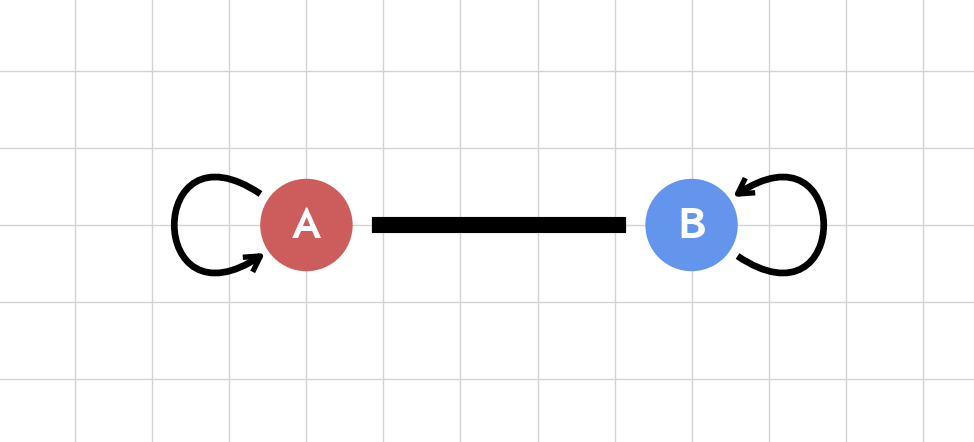

We'll define the natural frequencies $f_A$ and $f_B$ and a pump frequency `f_p`. These could have `node_ID`s `0` and `1` and the associated edge would be defined with the attributes `from_node_id = 0` and `to_node_id = 1`. The corresponding driven frequency list is then `[0, f_p]`. Things get a little trickier with amplification. Take the simplest 2-mode amplifier graph:

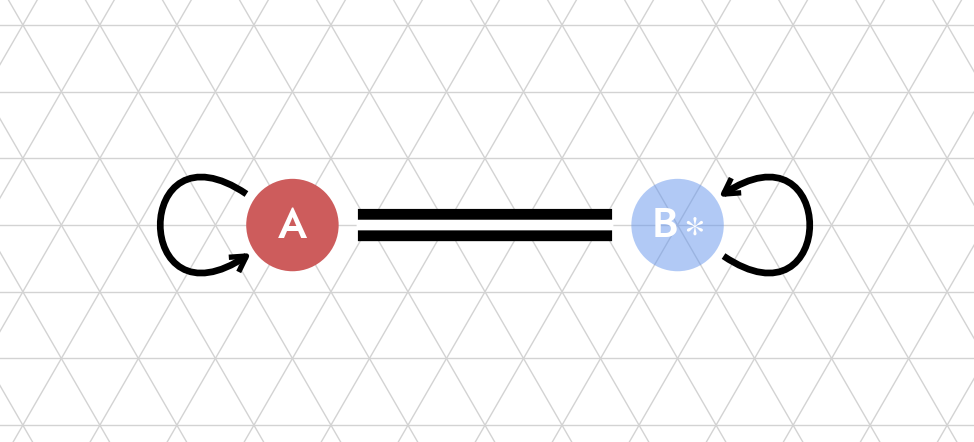

To get amplification, we would want the pump frequency to mix from $\sim f_A$ to $\sim -f_B$ (where the natural frequencies $f_A$ and $f_B$ are positive by convention). This requires a pump frequency $f_p \sim f_A + f_B$. This is essentially a downconversion since is translates signal near $f_A$ 'downwards' (i.e., in the negative frequency direction) to $\sim -f_B$. For this reason our driven frequency list would then be `[0, -f_p]`. In general, we have to provide signs on all of the edge pump frequencies which correspond to the direction that we want to translate to and it's up to the user to do this correctly in the graph scattering parameters assignment.

Above we defined a *driven frequency list*. If you drive into the first mode $A$ with some signal $f_A^s$ (in our NJP paper notation), it will translate to the two first order sideband frequencies $f_A^s \pm f_p$. Selection of the sign tells you exactly what you're coupling to if you were to draw the mode frequencies on a number line. We define the drive frequency list by traversing all of the branches of the spanning tree and accumulating a total frequency translation as we propagate to the end of each node.

Let's do an example based on the 3-mode "Delta" amplifier. The fully-decorated (original Ranzani/Aumentado) looks like this:

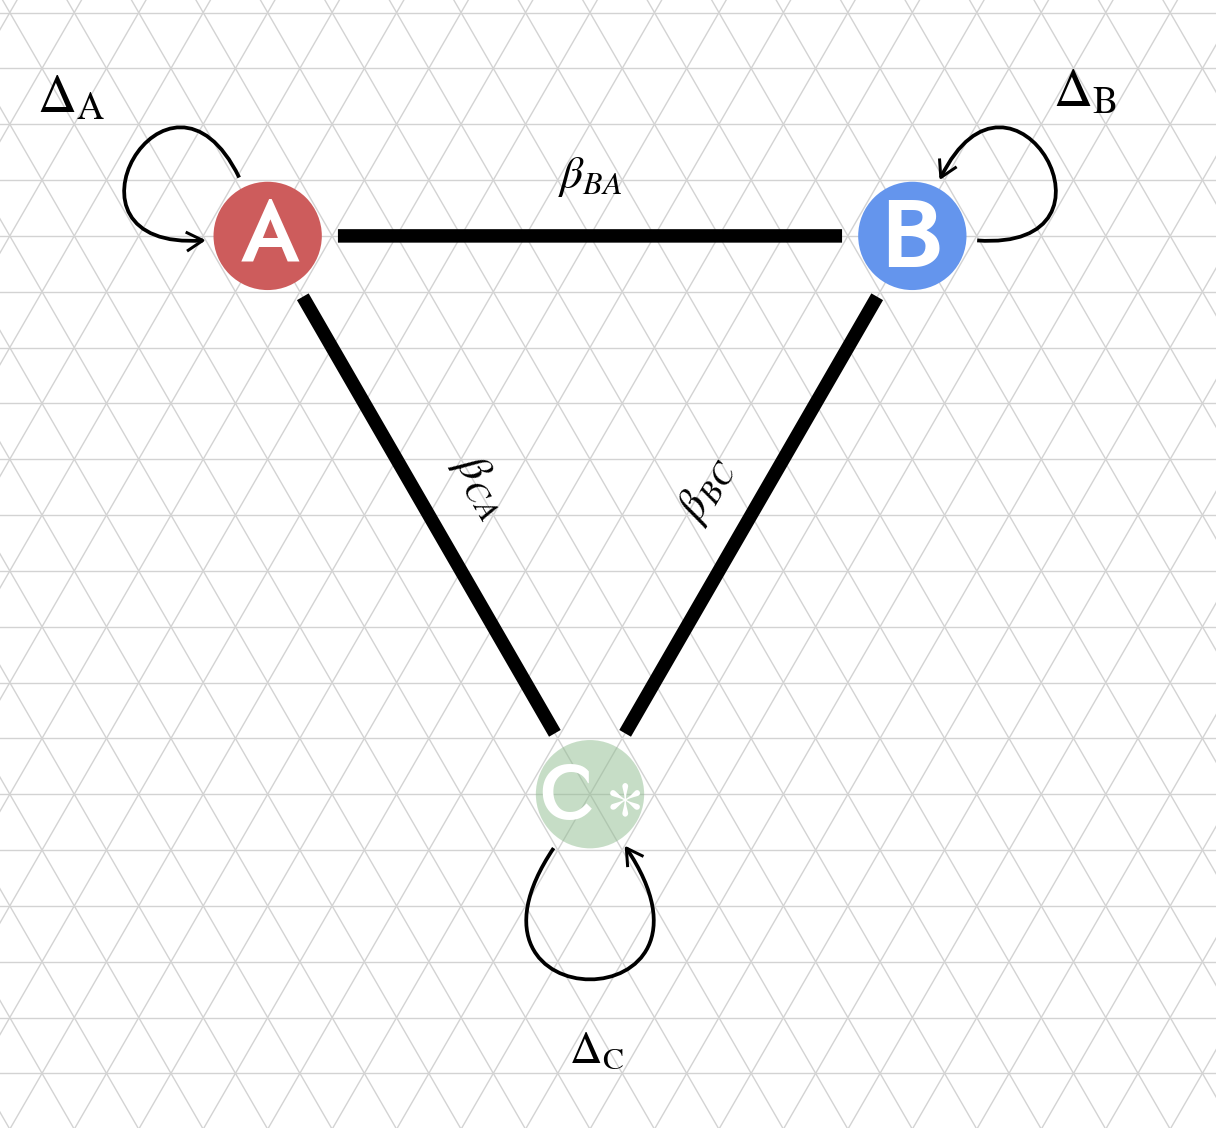

While with the abbreviated Naaman/Aumentado style used by the `paragraphulator` GUI looks like this:
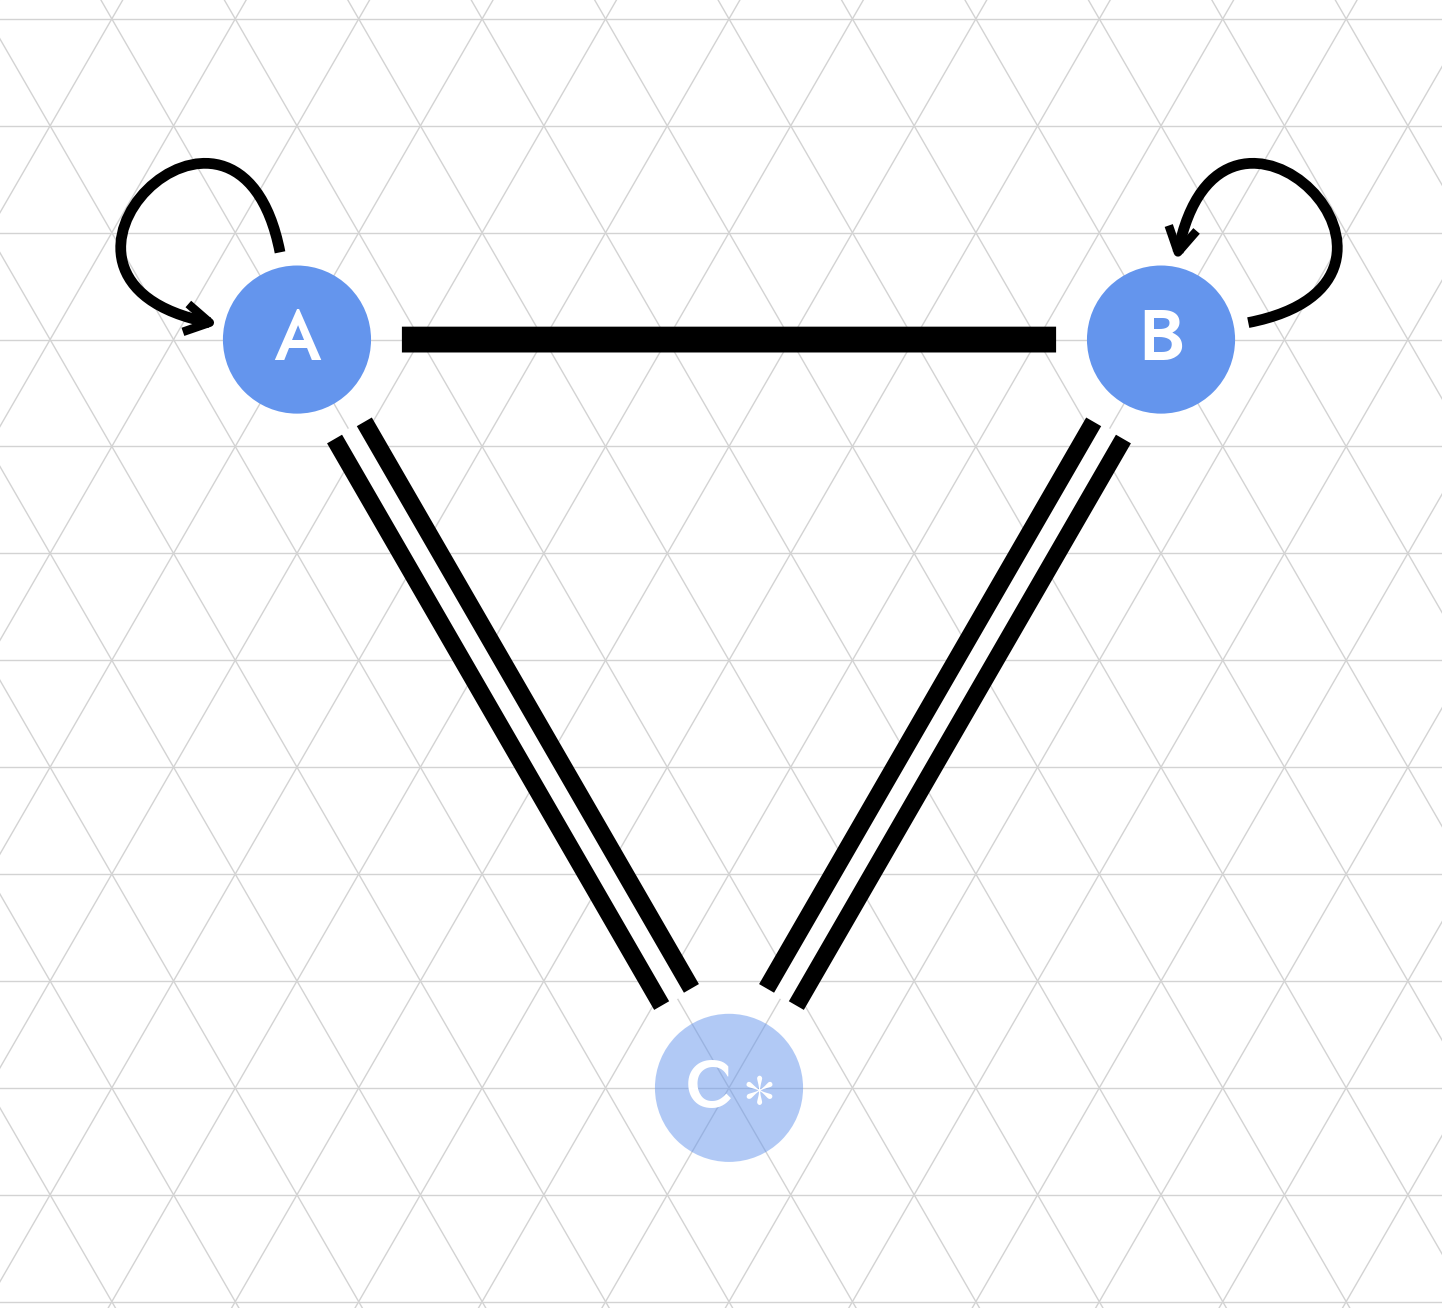


Both indicate the following equation of motion matrix:
$$
\mathbf{M} = \begin{bmatrix}
\Delta_{A} & \beta_{AB} & \beta_{AC} \\\\
\beta_{AB}^{*} & \Delta_{B} & \beta_{BC} \\\\
-\beta_{AC}^{*} & -\beta_{BC}^{*} & -\Delta_{C}^{*}
\end{bmatrix}
$$

In the abbreviated Naaman/Aumentado notation, the presence of self-loops indicate that a port is attached and available for computing scattering to/from. Nodes (modes) without self-loops still have internal loss specified (which you can think of as just hidden dissipative degrees of freedom), but the number of ports will define a the structure of the $\mathbf{K}$ external coupling matrix when we compute scattering. So if $N_\text{ports} < N_\text{modes}$ we will have non-square $\mathbf{K}$ with dimension $N_\text{modes}\times N_\text{ports}$. We'll go into this in more detail below when we compute scattering from the EoM matrix $\mathbf{M}$.

In [151]:
# 3-mode circulator graph
pgraph_data = load_pgraph('CIRC_FULL_SCATT_ABC.pgraph')
extractor = GraphExtractor()
extractor.extract_from_pgraph(pgraph_data, root_node_id=0) # Specify root node ID explicitly

# Delta amplifier graph
# pgraph_data = load_pgraph('DELTAAMP_FULL_SCATT_CBA.pgraph')
# extractor = GraphExtractor()
# extractor.extract_from_pgraph(pgraph_data, root_node_id=0) # Specify root node ID explicitly

Loaded pgraph: CIRC_FULL_SCATT_ABC.pgraph
  Nodes: 3
  Edges: 5
  Scattering data: ✓
    Tree edges: 2
    Chord edges: 1


{'nodes': [{'node_id': 0,
   'label': 'A',
   'pos': [-5.0, 3.4641016151377544],
   'conj': False,
   'freq': 5.0,
   'B_int': 0.0,
   'B_ext': 1.0},
  {'node_id': 1,
   'label': 'B',
   'pos': [2.0, 3.4641016151377544],
   'conj': False,
   'freq': 6.0,
   'B_int': 0.0,
   'B_ext': 1.0},
  {'node_id': 2,
   'label': 'C',
   'pos': [-1.5, -2.598076211353316],
   'conj': False,
   'freq': 8.0,
   'B_int': 0.0,
   'B_ext': None}],
 'edges': [{'from_node_id': 0,
   'to_node_id': 1,
   'is_self_loop': False,
   'f_p': 1.0,
   'rate': 1.0,
   'phase': 90.0},
  {'from_node_id': 1,
   'to_node_id': 2,
   'is_self_loop': False,
   'f_p': 2.0,
   'rate': 1.0,
   'phase': 0.0},
  {'from_node_id': 2,
   'to_node_id': 0,
   'is_self_loop': False,
   'f_p': 3.0,
   'rate': 1.0,
   'phase': 0.0},
  {'from_node_id': 0,
   'to_node_id': 0,
   'is_self_loop': True,
   'f_p': None,
   'rate': None,
   'phase': None},
  {'from_node_id': 1,
   'to_node_id': 1,
   'is_self_loop': True,
   'f_p': None,
   '

In [152]:
num_modes = len(extractor.graph_data['nodes'])
# Define a zeroed scattering matrix and we'll fill it in
M = np.zeros((num_modes, num_modes), dtype=complex)

Let's assemble the diagonals. We need to assign a driven signal frequency for each mode using the translated driven/signal frequency lists. Remember that these are referenced to the root, i.e., if you drive the signal frequency $f_\text{root}^s$ into the root node, the parametrically translated frequencies are $f_\text{root}$ plus the driven signal frequency list.

Let's look at how these lists are structured:

In [153]:
extractor.get_accumulated_frequencies()

[[(0, 0.0), (1, 1.0), (2, 3.0)]]

The tuples list the node index and the shifted frequency. Note that the root node always has zero translatoin by definition. Likewise, resonantly coupled modes should see no frequency shift relative to each other along their branch. When we compute scattering there will be a choice about whether to cast the frequency axis in terms of the source or receiver frequencies, although this is mitigated a little bit if we choose to plot signal detunings (relative to the mode natural frequencies) instead.

To get the full translated driven frequencies we just add our signal frequency $f_\text{root}^s$ to this list. Let's flatten, then iterate through to build the total driven frequency list for all nodes.

In [154]:
from more_itertools import collapse

# nested = [1, [2, [3, 4], 5], [6, [7, [8, 9]]]]
# flat = list(collapse(nested))
accumulated_frequencies_flattened = list(collapse(extractor.get_accumulated_frequencies(),base_type=tuple))
accumulated_frequencies_flattened

[(0, 0.0), (1, 1.0), (2, 3.0)]

In [155]:
# example f_root_s
# f_root_s = 7.8  # GHz # near the root node frequency, mode C
f_root_s = 4.8 # GHz neaer the root node frequency, mode A

drive_signals = []
for item in accumulated_frequencies_flattened:
    node_id, f_offset = item
    f_drive = f_root_s + f_offset
    drive_signals.append((node_id, f_drive))

drive_signals = dict(drive_signals) # turn it into a dict so that we can index by node ID
drive_signals   

{0: 4.8, 1: 5.8, 2: 7.8}

With this in hand, we can now assemble the diagonal elements. The general form for an unconjugated mode is

$$
M_{jj} = \Delta_j = f_j^s - f_j + i B_{j,\text{tot}}/2
$$

and for a conjugated mode, we write the anticonjugate

$$
M_{jj} = -\Delta_j^* = -f_j^s + f_j + i B_{j,\text{tot}}/2.
$$

Here $f_j^s$ are the driven mode frequencies. Since our usual convention is to keep the frequencies postive we have to remember that our driven signal frequency list casts these frequencies as negative numbers (breaking the convention). 

Since the nodes list is already ordered according to whatever the user did when they saved the `.pgraph` file, we can just go and iterate through the nodes and assign out the diagonals:



In [157]:
for idx, node in enumerate(extractor.graph_data['nodes']):
    node_id = node['node_id']
    f0 = node['freq']
    if node['B_ext'] is None:
        Btot = node['B_int']
    else:
        Btot = node['B_int'] + node['B_ext']
    conj_state = node['conj']

    f_drive = drive_signals[node_id]
    print(f"Node {node_id} ({node['label']}): Driven frequency = {f_drive} GHz")
    print(f"Natural frequency = {f0} GHz, Conjugated: {conj_state}")
    if conj_state:
        assert f_drive < f0, "Error: For conjugated nodes, driven frequency must be less than natural frequency. Check the accumulated frequency list."
        M[idx, idx] = f_drive + f0 + Btot * 1j/2 # f_drive should be negative here
    else: # unconjugated diagonal
        M[idx, idx] = f_drive - f0 + Btot * 1j/2

# check it:
# all imaginary terms should be positive (correct damping)
M

Node 0 (A): Driven frequency = 4.8 GHz
Natural frequency = 5.0 GHz, Conjugated: False
Node 1 (B): Driven frequency = 5.8 GHz
Natural frequency = 6.0 GHz, Conjugated: False
Node 2 (C): Driven frequency = 7.8 GHz
Natural frequency = 8.0 GHz, Conjugated: False


array([[-0.2+0.5j,  0. +0.j ,  0. +0.j ],
       [ 0. +0.j , -0.2+0.5j,  0. +0.j ],
       [ 0. +0.j ,  0. +0.j , -0.2+0.j ]])

## Off-diagonals
Let's now assign the off-diagonal $\beta_{jk}$. For frequency converter (FC)-type couplings, means that $M_{jk} = M_{kj}^*$ and for amplifier (PA)-type couplings we have $M_{jk} = - M_{kj}^*$. We have FC-type couplings for directly coupled mode pairs that share the same conjugation state, and have PA-type couplings for pairs that are mixed conjugation. This means that we have to evaluate the $j,k$ mode conjugation states when we assign the matrix elements. Lastly, we have set up a convention that regardless of how the mode basis is ordered, we will keep the upper right triangle of complex coupling values the reference un-conjugated betas. This means we have to also check how the edge `from_node_id` and `to_node_id` values are ordered with respect to the node basis order so that we assign conjugation according to this convention.

In [158]:
extractor.graph_data['edges']

[{'from_node_id': 0,
  'to_node_id': 1,
  'is_self_loop': False,
  'f_p': 1.0,
  'rate': 1.0,
  'phase': 90.0},
 {'from_node_id': 1,
  'to_node_id': 2,
  'is_self_loop': False,
  'f_p': 2.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 2,
  'to_node_id': 0,
  'is_self_loop': False,
  'f_p': 3.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 0,
  'to_node_id': 0,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None},
 {'from_node_id': 1,
  'to_node_id': 1,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None}]

In [159]:
# get the mode basis order
basis = extractor.graph_data['basis_order']

for edge in extractor.graph_data['edges']:
    from_id = edge['from_node_id']
    to_id = edge['to_node_id']

    # get the basis indices
    j = basis.index(from_id)
    k = basis.index(to_id)

    if j != k:
        f_p = edge['f_p']
        rate = edge['rate']
        phase = edge['phase']

        print(f"Edge: {from_id} -> {to_id} | Basis indices: j={j}, k={k} | f_p={f_p}, rate={rate}, phase={phase}")
        beta = rate * np.exp(1j * phase * np.pi / 180)

        # get conjugation states
        conj_j = extractor.graph_data['nodes'][j]['conj']
        conj_k = extractor.graph_data['nodes'][k]['conj']

        # Determine if this is FC or PA type coupling
        if conj_j == conj_k:
            # FC-type coupling
            if j < k:
                M[j, k] = beta
                M[k, j] = np.conj(beta)
            else:
                M[k, j] = beta
                M[j, k] = np.conj(beta)
        else:
            # PA-type coupling
            if j < k:
                M[j, k] = beta
                M[k, j] = -np.conj(beta)
            else:
                M[k, j] = beta
                M[j, k] = -np.conj(beta)

Edge: 0 -> 1 | Basis indices: j=0, k=1 | f_p=1.0, rate=1.0, phase=90.0
Edge: 1 -> 2 | Basis indices: j=1, k=2 | f_p=2.0, rate=1.0, phase=0.0
Edge: 2 -> 0 | Basis indices: j=2, k=0 | f_p=3.0, rate=1.0, phase=0.0


In [160]:
M

array([[-2.000000e-01+0.5j,  6.123234e-17+1.j ,  1.000000e+00+0.j ],
       [ 6.123234e-17-1.j , -2.000000e-01+0.5j,  1.000000e+00+0.j ],
       [ 1.000000e+00-0.j ,  1.000000e+00-0.j , -2.000000e-01+0.j ]])

## Build the scattering matrix $\mathbf{S}$
The $\mathbf{M}$ matrix can be used to build the $\mathbf{S}$ matrix. Since, in this formulation we do not in general provide a port attached to every mode we have to be able to take a subset of the full scattering matrix. We can do this by defining non-square $\mathbf{K}$ defining the external coupling rates.

As noted above, only nodes with self-loops are counted as ports for scattering. We can either scan through the edge list looking for `from_node_id`s equal to `to_node_id`s and then finding the corresponding node's $B_\text{ext}$ value, or we can scan the nodes that have $B_\text{ext}$ defined since nodes without ports shouldn't have this defined in the first place. To make things easier, we just add a `get_ports()` method to the `GraphExtractor` class to tell us both the `node_id` and the $B_\text{ext}$ value.

In [161]:
port_dict = {}

for node in extractor.graph_data['nodes']:
    node_id = node['node_id']

    if node['B_ext'] is not None and node['B_ext'] > 0:
        port_dict[node_id] = node['B_ext']

port_dict

{0: 1.0, 1: 1.0}

Let's put this all together into a class to compute $\mathbf{M}$ from a graph:

In [ ]:
class GraphScatteringMatrix:
    '''Class to build the scattering matrix S from an EoM "M" matrix built
     using a GraphExtractor graph data and an array of drive frequencies.
     '''

    def __init__(self, extractor: GraphExtractor, f_root_s: np.ndarray):
        self.extractor = extractor
        self.f_root_s = f_root_s
        self.num_modes = len(extractor.graph_data['nodes'])
        self.M = np.zeros((len(self.f_root_s), self.num_modes, self.num_modes), dtype=complex)

        self._build_f_drivesignals()
        self._build_M_matrix()
        self._build_K_matrix()
        self._build_S_matrix()

    def _build_f_drivesignals(self):
        accumulated_frequencies_flattened = list(
            collapse(self.extractor.get_accumulated_frequencies(), base_type=tuple)
        )
        self.drive_signals = {
            node_id: self.f_root_s + f_offset
            for node_id, f_offset in accumulated_frequencies_flattened
        }

    def _build_M_matrix(self):
        # Assemble diagonals
        accumulated_frequencies_flattened = list(
            collapse(self.extractor.get_accumulated_frequencies(), base_type=tuple)
        )


        for idx, node in enumerate(self.extractor.graph_data['nodes']):
            node_id = node['node_id']
            f0 = node['freq']
            if node['B_ext'] is None:
                Btot = node['B_int']
            else:
                Btot = node['B_int'] + node['B_ext']
            conj_state = node['conj']

            for f_idx, f_root in enumerate(self.f_root_s):
                # Compute drive signals for this f_root
                drive_signals = {
                    node_id: f_root + f_offset
                    for node_id, f_offset in accumulated_frequencies_flattened
                }

                f_drive = drive_signals[node_id]

                if conj_state:
                    self.M[f_idx, idx, idx] = f_drive + f0 + Btot * 1j / 2
                else:
                    self.M[f_idx, idx, idx] = f_drive - f0 + Btot * 1j / 2

        # Assemble off-diagonals
        basis = self.extractor.graph_data['basis_order']
        for edge in self.extractor.graph_data['edges']:
            from_id = edge['from_node_id']
            to_id = edge['to_node_id']

            j = basis.index(from_id)
            k = basis.index(to_id)

            if j != k:
                # f_p = edge['f_p']
                rate = edge['rate']
                phase = edge['phase']

                beta = rate/2 * np.exp(1j * phase * np.pi / 180)

                conj_j = self.extractor.graph_data['nodes'][j]['conj']
                conj_k = self.extractor.graph_data['nodes'][k]['conj']

                if conj_j == conj_k:
                    if j < k:
                        self.M[:, j, k] = beta
                        self.M[:, k, j] = np.conj(beta)
                    else:
                        self.M[:, k, j] = beta
                        self.M[:, j, k] = np.conj(beta)
                else:
                    if j < k:
                        self.M[:, j, k] = beta
                        self.M[:, k, j] = -np.conj(beta)
                    else:
                        self.M[:, k, j] = beta
                        self.M[:, j, k] = -np.conj(beta)   

    def _build_K_matrix(self):
        self.port_dict = {}
        
        for node in self.extractor.graph_data['nodes']:
            node_id = node['node_id']
            # print(node)
            if node['B_ext'] is not None and node['B_ext'] > 0:
                self.port_dict[node_id] = node['B_ext']
                # print(f"Added port: {node_id} with B_ext={node['B_ext']}")
        
        self.num_ports = len(self.port_dict)

        # print("Port dict constructed:", self.port_dict)
        self.K = np.zeros(shape=(self.num_modes, len(self.port_dict)), dtype=float)
    
        for node_id, B_ext in self.port_dict.items():
            mode_idx = self.extractor.graph_data['basis_order'].index(node_id)
            port_idx = list(self.port_dict.keys()).index(node_id)
            self.K[mode_idx, port_idx] = np.sqrt(B_ext)

    def _build_S_matrix(self):
        self.S = np.empty(shape=(len(self.f_root_s), self.num_ports, self.num_ports), dtype=complex)
        self.SdB = np.empty(shape=(len(self.f_root_s), self.num_ports, self.num_ports), dtype=float)
        for idx,_ in enumerate(self.f_root_s):
            M = self.M[idx,:,:]
            I = np.eye(self.num_ports)
            K = self.K

            self.S[idx,:,:] = 1j * K.T @ np.linalg.inv(M) @ K - I
            self.SdB[idx,:,:] = 20 * np.log10(np.abs(self.S[idx,:,:]))

    


In [216]:
pgraph_data = load_pgraph('CIRC_FULL_SCATT_ABC.pgraph')
extractor = GraphExtractor()
extractor.extract_from_pgraph(pgraph_data, root_node_id=0) # Specify root node ID explicitly

gsm = GraphScatteringMatrix(extractor, f_root_s = np.linspace(3.0, 7.0, 801)+1e-6)
# gsm.K

Loaded pgraph: CIRC_FULL_SCATT_ABC.pgraph
  Nodes: 3
  Edges: 5
  Scattering data: ✓
    Tree edges: 2
    Chord edges: 1


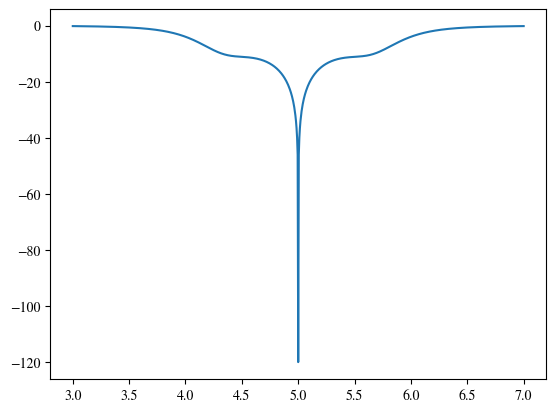

In [217]:
from matplotlib import pyplot as pyplot

k = 0
m = 0
plt.plot(gsm.drive_signals[k], gsm.SdB[:,m,k])

In [207]:
gsm.K

array([[1., 0.],
       [0., 1.],
       [0., 0.]])

In [208]:
gsm.M[:2,:,:]

array([[[-1.999999e+00+0.5j,  3.061617e-17+0.5j,  5.000000e-01+0.j ],
        [ 3.061617e-17-0.5j, -1.999999e+00+0.5j,  5.000000e-01+0.j ],
        [ 5.000000e-01-0.j ,  5.000000e-01-0.j , -1.999999e+00+0.5j]],

       [[-1.959999e+00+0.5j,  3.061617e-17+0.5j,  5.000000e-01+0.j ],
        [ 3.061617e-17-0.5j, -1.959999e+00+0.5j,  5.000000e-01+0.j ],
        [ 5.000000e-01-0.j ,  5.000000e-01-0.j , -1.959999e+00+0.5j]]])

# DEBUG CHORD FREQUENCY CALCS
I see a problem in `DTWPA_MINIMAL_2.pgraph`. Let's load it and see what gets computed.

In [249]:
pgraph_data = load_pgraph('DTWPA_MINIMAL2.pgraph')
extractor = GraphExtractor()
# extractor.extract_from_pgraph(pgraph_data, root_node_id=0) # Specify root node ID explicitly
extractor.extract_from_pgraph(pgraph_data, root_node_id=9) # Specify root node ID explicitly


Loaded pgraph: DTWPA_MINIMAL2.pgraph
  Nodes: 6
  Edges: 12
  Scattering data: ✓
    Tree edges: 5
    Chord edges: 3


{'nodes': [{'node_id': 9,
   'label': '0',
   'pos': [-10.0, 12.0],
   'conj': False,
   'freq': 5.0,
   'B_int': 0.0,
   'B_ext': 0.1},
  {'node_id': 10,
   'label': '1',
   'pos': [-6.0, 12.0],
   'conj': False,
   'freq': 5.0,
   'B_int': 0.0,
   'B_ext': None},
  {'node_id': 12,
   'label': '2',
   'pos': [-2.0, 12.0],
   'conj': False,
   'freq': 5.0,
   'B_int': 0.0,
   'B_ext': 0.1},
  {'node_id': 13,
   'label': '3',
   'pos': [-10.0, 8.0],
   'conj': True,
   'freq': 7.0,
   'B_int': 0.0,
   'B_ext': 0.1},
  {'node_id': 14,
   'label': '4',
   'pos': [-6.0, 8.0],
   'conj': True,
   'freq': 7.0,
   'B_int': 0.0,
   'B_ext': None},
  {'node_id': 15,
   'label': '5',
   'pos': [-2.0, 8.0],
   'conj': True,
   'freq': 7.0,
   'B_int': 0.0,
   'B_ext': 0.1}],
 'edges': [{'from_node_id': 9,
   'to_node_id': 10,
   'is_self_loop': False,
   'f_p': 0.0,
   'rate': 0.10000000000000003,
   'phase': 0.0},
  {'from_node_id': 10,
   'to_node_id': 12,
   'is_self_loop': False,
   'f_p': 0.

In [250]:
extractor.graph_data['tree_edges']

[[[9, 10, 0.0]],
 [[10, 13, 12.0]],
 [[10, 12, 0.0], [12, 14, 12.0], [14, 15, 0.0]]]

In [251]:
extractor.get_accumulated_frequencies()

[[(9, 0.0), (10, 0.0)],
 [(10, 0.0), (13, -12.0)],
 [(10, 0.0), (12, 0.0), (14, -12.0), (15, -12.0)]]

In [252]:
extractor.get_chord_frequencies()

{(10, 15): 12.0, (13, 14): 0.0, (9, 14): 12.0}

In [253]:
extractor.get_edge_list()

[(9, 10), (10, 12), (13, 14), (14, 15), (9, 14), (13, 10), (10, 15), (14, 12)]

In [52]:
# Example: Create a simple parametric graph to demonstrate automatic computation
# This example shows a 4-node graph with mixed conversion and amplification

# Define a simple example graph structure
example_pgraph_data = {
    'nodes': [
        {'node_id': 0, 'label': 'A', 'pos': (0.0, 0.0), 'conj': False, 'freq': 5.0, 'B_int': 0.1, 'B_ext': 1.0},
        {'node_id': 1, 'label': 'B*', 'pos': (1.0, 0.0), 'conj': True, 'freq': 6.0, 'B_int': 0.1, 'B_ext': 1.0},
        {'node_id': 2, 'label': 'C', 'pos': (2.0, 0.0), 'conj': False, 'freq': 7.0, 'B_int': 0.1, 'B_ext': 1.0},
        {'node_id': 3, 'label': 'D*', 'pos': (1.0, 1.0), 'conj': True, 'freq': 8.0, 'B_int': 0.1, 'B_ext': 1.0},
    ],
    'edges': [
        {'from_node_id': 0, 'to_node_id': 1, 'is_self_loop': False, 'f_p': 11.0, 'rate': 1.0, 'phase': 0.0},
        {'from_node_id': 1, 'to_node_id': 2, 'is_self_loop': False, 'f_p': 13.0, 'rate': 1.0, 'phase': 0.0},
        {'from_node_id': 2, 'to_node_id': 3, 'is_self_loop': False, 'f_p': 15.0, 'rate': 1.0, 'phase': 0.0},
        {'from_node_id': 0, 'to_node_id': 3, 'is_self_loop': False, 'f_p': None, 'rate': 1.0, 'phase': 0.0},  # Chord - f_p auto-computed
        # Self-loops
        {'from_node_id': 0, 'to_node_id': 0, 'is_self_loop': True, 'f_p': None, 'rate': None, 'phase': None},
        {'from_node_id': 1, 'to_node_id': 1, 'is_self_loop': True, 'f_p': None, 'rate': None, 'phase': None},
        {'from_node_id': 2, 'to_node_id': 2, 'is_self_loop': True, 'f_p': None, 'rate': None, 'phase': None},
        {'from_node_id': 3, 'to_node_id': 3, 'is_self_loop': True, 'f_p': None, 'rate': None, 'phase': None},
    ],
    'frequency': {'start': 0.0, 'stop': 10.0, 'points': 100},
}

# Extract the graph - this automatically computes:
# 1. Spanning tree decomposition
# 2. Branch grouping
# 3. Accumulated frequencies along branches
# 4. Chord pump frequencies
extractor = GraphExtractor()
extractor.extract_from_pgraph(example_pgraph_data, root_node_id=0)

# Access the extracted data
nodes = extractor.graph_data['nodes']
edges = extractor.graph_data['edges']
tree = extractor.graph_data['tree_edges']
chords = extractor.graph_data['chord_edges']

# Display the results
print("=" * 70)
print("EXAMPLE GRAPH: 0(A) → 1(B*) → 2(C) → 3(D*) with chord 0→3")
print("=" * 70)
print(f"\nRoot node: {extractor.graph_data['root_node_id']}")
print(f"Nodes: {len(nodes)} ({[n['label'] for n in nodes]})")
print(f"  Node frequencies: {[f\"{n['label']}: {n['freq']} GHz\" for n in nodes]}")
print(f"  Conjugated nodes: {[n['label'] for n in nodes if n['conj']]}")

print(f"\nTree edges (by branch):")
for i, branch in enumerate(tree, 1):
    if branch:
        path = ' → '.join([str(branch[0][0])] + [str(e[1]) for e in branch])
        f_p_values = [f"{e[2]}" if e[2] is not None else "None" for e in branch]
        print(f"  Branch {i}: {path}")
        print(f"    Pump frequencies: {', '.join(f_p_values)} GHz")

print(f"\nChord edges: {chords}")

# Show automatically computed frequencies
print("\n" + "=" * 70)
print("AUTOMATIC COMPUTATIONS (no user intervention needed!)")
print("=" * 70)

accum = extractor.get_accumulated_frequencies()
print("\nAccumulated frequencies along each branch:")
for i, branch_accum in enumerate(accum, 1):
    print(f"  Branch {i}:")
    for node_id, f_offset in branch_accum:
        node = nodes[node_id]
        conj_str = "*" if node['conj'] else ""
        print(f"    Node {node_id}({node['label']}): {f_offset:+.1f} GHz")

chord_freqs = extractor.get_chord_frequencies()
print(f"\nChord pump frequencies (auto-computed from accumulated freq):")
for (from_id, to_id), f_p in chord_freqs.items():
    from_label = nodes[from_id]['label']
    to_label = nodes[to_id]['label']
    print(f"  Chord {from_id}({from_label})→{to_id}({to_label}): f_p = {f_p} GHz")
    print(f"    Calculated as: |accum[{from_id}] - accum[{to_id}]| = |{accum[0][from_id][1]} - {accum[0][to_id][1]}| = {f_p}")

# IMPORTANT: Verify that the chord edge in graph_data['edges'] was updated!
print(f"\n" + "=" * 70)
print("VERIFICATION: Chord edge f_p in graph_data['edges'] list")
print("=" * 70)
print("\nAll non-self-loop edges:")
for edge in edges:
    if not edge.get('is_self_loop', False):
        from_id = edge['from_node_id']
        to_id = edge['to_node_id']
        from_label = nodes[from_id]['label']
        to_label = nodes[to_id]['label']
        
        # Check if this is a chord
        is_chord = any(
            (c[0] == from_id and c[1] == to_id) or (c[0] == to_id and c[1] == from_id)
            for c in chords
        )
        
        chord_marker = " [CHORD - AUTO-COMPUTED]" if is_chord else " [tree edge - user provided]"
        print(f"  Edge {from_id}({from_label})→{to_id}({to_label}): f_p = {edge['f_p']}{chord_marker}")

print("\n" + "=" * 70)
print("✓ All frequencies computed automatically on extraction!")
print("✓ Chord edges automatically assigned in graph_data['edges']!")
print("✓ Updates automatically when you modify parameters!")
print("✓ Rounded to 12 decimal places to avoid floating-point errors!")
print("=" * 70)

SyntaxError: unexpected character after line continuation character (1410394226.py, line 46)

In [ ]:
# OVERRIDE TREE TO SHOW HOW THE FREQUENCY PROPAGATION WORKS
tree = [
    (1, 2, 0.5),
    (1, 3, 0.8),
    (2, 4, 0.6),
    (2, 5, 0.7),
    (3, 6, 0.9)
]

[[0, 2, None], [1, 2, 2.0]]

In [46]:
# traverse each of the tree branches to fill in the driven frequency list, relative to the root.
for edge in tree:
    print(f"Tree Edge: {edge[0]} -> {edge[1]}")

Tree Edge: 0 -> 2
Tree Edge: 1 -> 2


In [47]:
tree

[[0, 2, None], [1, 2, 2.0]]

In [48]:
edges

[{'from_node_id': 0,
  'to_node_id': 1,
  'is_self_loop': False,
  'f_p': 1.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 1,
  'to_node_id': 2,
  'is_self_loop': False,
  'f_p': 2.0,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 2,
  'to_node_id': 0,
  'is_self_loop': False,
  'f_p': None,
  'rate': 1.0,
  'phase': 0.0},
 {'from_node_id': 0,
  'to_node_id': 0,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None},
 {'from_node_id': 1,
  'to_node_id': 1,
  'is_self_loop': True,
  'f_p': None,
  'rate': None,
  'phase': None}]